11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1, Loss: 2.2194
Epoch 2, Loss: 1.9912
Epoch 3, Loss: 1.8040
Epoch 4, Loss: 1.6472
Epoch 5, Loss: 1.5149


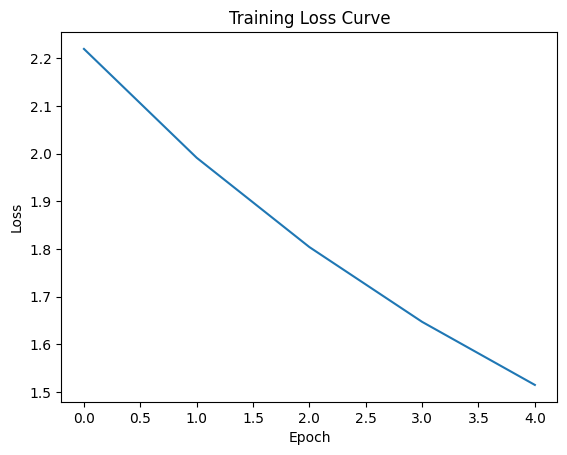

Test Accuracy: 0.69


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

# Load MNIST (fast)
(X, y), _ = mnist.load_data()
X = X / 255.0

# Use small subset
X = X[:1000]
y = y[:1000]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Initialize parameters
num_filters = 2
filter_size = 3
filters = np.random.randn(num_filters, filter_size, filter_size) / 9

fc_weights = np.random.randn(13*13*2, 10) / 100
learning_rate = 0.01

# Convolution
def convolve(image, filters):
    h, w = image.shape
    f = filters.shape[1]
    output = np.zeros((h - f + 1, w - f + 1, filters.shape[0]))

    for k in range(filters.shape[0]):
        for i in range(h - f + 1):
            for j in range(w - f + 1):
                region = image[i:i+f, j:j+f]
                output[i, j, k] = np.sum(region * filters[k])
    return output

# ReLU
def relu(x):
    return np.maximum(0, x)

# Max Pool
def maxpool(x):
    h, w, d = x.shape
    output = np.zeros((h//2, w//2, d))

    for k in range(d):
        for i in range(0, h, 2):
            for j in range(0, w, 2):
                output[i//2, j//2, k] = np.max(x[i:i+2, j:j+2, k])
    return output

# Softmax (stable)
def softmax(x):
    exp = np.exp(x - np.max(x))
    return exp / np.sum(exp)

# Training step
def train_step(image, label):
    global fc_weights

    conv = convolve(image, filters)
    relu_out = relu(conv)
    pool = maxpool(relu_out)
    flat = pool.flatten()

    logits = np.dot(flat, fc_weights)
    probs = softmax(logits)

    probs = np.clip(probs, 1e-10, 1.0)  # stability

    loss = -np.log(probs[label])

    # Backprop (FC only)
    dL = probs
    dL[label] -= 1

    dW = np.outer(flat, dL)
    fc_weights -= learning_rate * dW

    return loss

# Training loop
losses = []

for epoch in range(5):
    total_loss = 0
    for i in range(200):
        total_loss += train_step(X_train[i], y_train[i])

    avg_loss = total_loss / 200
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Plot loss
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

# Testing
correct = 0
for i in range(100):
    conv = convolve(X_test[i], filters)
    relu_out = relu(conv)
    pool = maxpool(relu_out)
    flat = pool.flatten()

    logits = np.dot(flat, fc_weights)
    pred = np.argmax(logits)

    if pred == y_test[i]:
        correct += 1

print("Test Accuracy:", correct / 100)